# **Deep Learning course project**                                   
           

# **creating folders and accessing data from google drive**

In [ ]:
import os
import random
import shutil
import zipfile
from pathlib import Path
from typing import Dict, List

import requests
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import DataLoader, WeightedRandomSampler

from torchvision import datasets, transforms, models

In [ ]:
#creating train/test split folder
data_path = Path("data/")
split_path = data_path / "split"

if split_path.is_dir():
  print(f"{split_path} directory exists, skipping download")
else:
  print(f"{split_path} does not exist, creating one...")
  split_path.mkdir(parents=True, exist_ok=True)

data/split does not exist, creating one...


In [ ]:
# downloading zipped data from google collab
!pip -q install gdown
import gdown

file_id = "1uzZ2OeXMWckJYtj62kO8ZzRYe4z4hfye"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1uzZ2OeXMWckJYtj62kO8ZzRYe4z4hfye
From (redirected): https://drive.google.com/uc?id=1uzZ2OeXMWckJYtj62kO8ZzRYe4z4hfye&confirm=t&uuid=0e0713dd-cc28-41ef-8be7-8855f2678ba6
To: /content/data.zip
100%|██████████| 614M/614M [00:11<00:00, 55.5MB/s]


'data.zip'

In [ ]:
#unzipping
!unzip -q data.zip

In [ ]:
# splitting the data into train and test folders
src_root = Path("raw-img/")
out_root = Path("data/split")
train_dir = out_root / "train"
test_dir  = out_root / "test"

test_ratio = 0.2
seed = 42
img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

random.seed(seed)

for class_dir in [p for p in src_root.iterdir() if p.is_dir()]:
    files = [f for f in class_dir.iterdir() if f.is_file() and f.suffix.lower() in img_exts]
    random.shuffle(files)

    n_test = int(len(files) * test_ratio)
    test_files = files[:n_test]
    train_files = files[n_test:]

    (train_dir / class_dir.name).mkdir(parents=True, exist_ok=True)
    (test_dir / class_dir.name).mkdir(parents=True, exist_ok=True)

    for f in train_files:
        shutil.copy2(f, train_dir / class_dir.name / f.name)

    for f in test_files:
        shutil.copy2(f, test_dir / class_dir.name / f.name)

print("Done. Split created at:", out_root)

Done. Split created at: data/split


# **Looking at the data**

In [ ]:
train_num = !find data/split/train -type f | wc -l
test_num =!find data/split/test  -type f | wc -l


print(f"number of training data images: {train_num}")
print(f"number of test data images: {test_num}")
print("classes:")
!ls data/split/train

number of training data images: ['20947']
number of test data images: ['5232']
classes:
cane	 elefante  gallina  mucca   ragno
cavallo  farfalla  gatto    pecora  scoiattolo


In [ ]:
#looking at number of images per animal in train/test folders
for dirpath, dirnames, filenames in os.walk(out_root):
  print(f"there are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

there are 2 directories and 0 images in data/split
there are 10 directories and 0 images in data/split/test
there are 0 directories and 333 images in data/split/test/gatto
there are 0 directories and 289 images in data/split/test/elefante
there are 0 directories and 972 images in data/split/test/cane
there are 0 directories and 619 images in data/split/test/gallina
there are 0 directories and 524 images in data/split/test/cavallo
there are 0 directories and 373 images in data/split/test/mucca
there are 0 directories and 372 images in data/split/test/scoiattolo
there are 0 directories and 964 images in data/split/test/ragno
there are 0 directories and 422 images in data/split/test/farfalla
there are 0 directories and 364 images in data/split/test/pecora
there are 10 directories and 0 images in data/split/train
there are 0 directories and 1335 images in data/split/train/gatto
there are 0 directories and 1157 images in data/split/train/elefante
there are 0 directories and 3891 images in d

Random image path: data/split/train/gatto/ea36b5062bf5013ed1584d05fb1d4e9fe777ead218ac104497f5c978a7e8b7bc_640.jpg
Image class: gatto
Image height: 640
Image width: 480


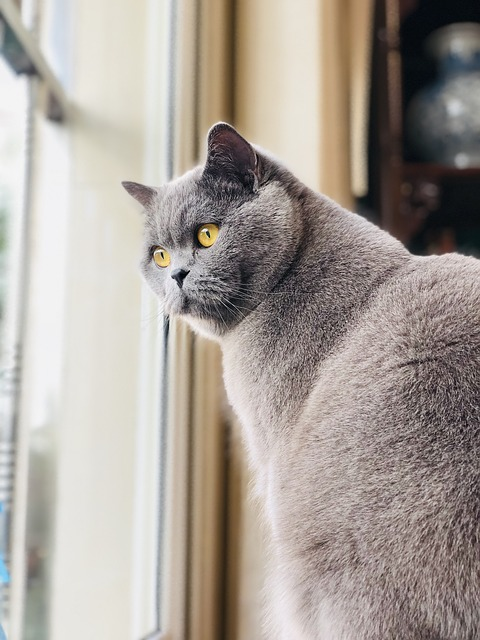

In [ ]:
#shows random images from the data with its label and HxW

import random
from PIL import Image


image_path_list = list(split_path.glob("*/*/*.jpg"))

#get random image path
random_image_path = random.choice(image_path_list)

# image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

# **Dataset and Dataloaders**

In [ ]:
#transforms for train and test data
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406), (0.229,0.224,0.225))
])

test_transform = transforms.Compose([
    transforms.Resize(144),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406), (0.229,0.224,0.225))
])


In [ ]:
# Plotting random images and their transformation.
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

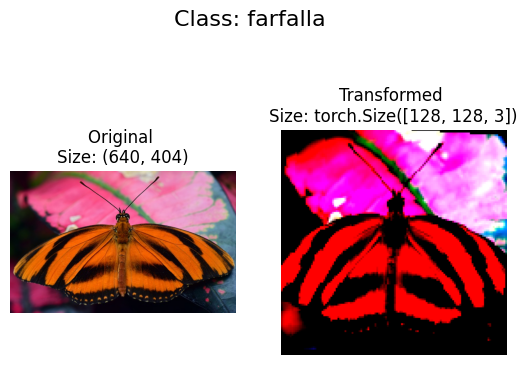

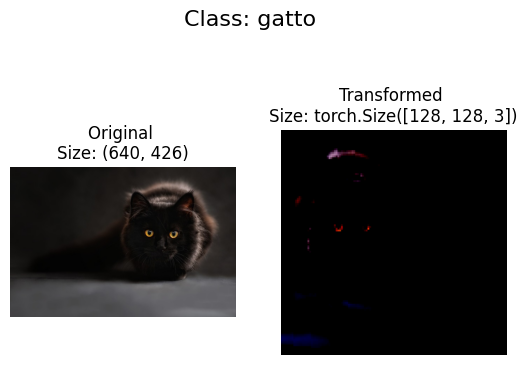

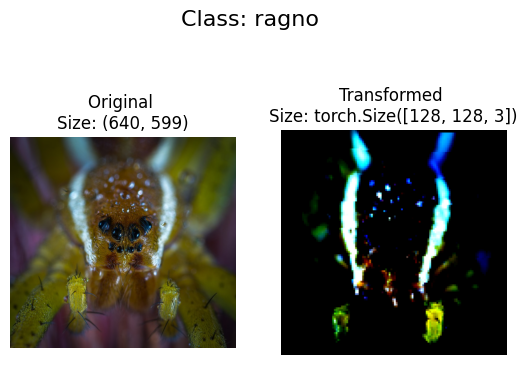

In [ ]:
plot_transformed_images(image_path_list,
                        transform=train_transform,
                        n=3)

In [ ]:
# using ImageFolder to create (img, label) pairs

train_data = datasets.ImageFolder(root=train_dir, # target folder of images
                                  transform=train_transform, # transforms to perform on data
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=test_transform)

In [ ]:
class_names = train_data.classes
class_names

['cane',
 'cavallo',
 'elefante',
 'farfalla',
 'gallina',
 'gatto',
 'mucca',
 'pecora',
 'ragno',
 'scoiattolo']

In [ ]:
class_dict = train_data.class_to_idx
class_dict

{'cane': 0,
 'cavallo': 1,
 'elefante': 2,
 'farfalla': 3,
 'gallina': 4,
 'gatto': 5,
 'mucca': 6,
 'pecora': 7,
 'ragno': 8,
 'scoiattolo': 9}

In [ ]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],

        [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],

        [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.

In [ ]:
NUM_WORKERS = os.cpu_count()

In [ ]:
# fixing imbalances with sampler
targets = np.array([y for _, y in train_data.samples])
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

# creating train/test Dataloaders
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32,
                              sampler=sampler,
                              num_workers=NUM_WORKERS,
                              pin_memory=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=64,
                             num_workers=NUM_WORKERS,
                             shuffle=False,
                             pin_memory=True)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7d55f9c5fec0>,
 <torch.utils.data.dataloader.DataLoader at 0x7d55ed0e2570>)

In [ ]:
img, label = next(iter(train_dataloader))

print(f"Image shape: {img.shape} -> [batch_size, color, height, width]")
print(f"Label shape: {label.shape}")

# **creating Model_0 inspired by the TinyVGG architecture as a baseline**

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int, img_size: int=128) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),

            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.10),
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),

            nn.Conv2d(hidden_units*2, hidden_units*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.10),
        )

        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(hidden_units*2, hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),

            nn.Conv2d(hidden_units*4, hidden_units*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units*4),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.10),
        )

        final_spatial = img_size // 8
        in_features = (hidden_units * 4) * final_spatial * final_spatial

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(in_features, output_shape)
        )



    def forward(self, x: torch.Tensor):
        x = self.classifier(self.conv_block_3((self.conv_block_2(self.conv_block_1(x)))))
        return x

torch.manual_seed(42)

In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               scheduler,
               optimizer: torch.optim.Optimizer):

    # Put model in train mode
    model.train()

    # train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # 6. Scheduler step
        scheduler.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [ ]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [ ]:
# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          scheduler,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           scheduler=scheduler,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    # 6. Return the results at the end of the epochs
    return results

In [ ]:
# Instantiating the model
model_0 = TinyVGG(input_shape=3,
                  hidden_units=64,
                  output_shape=len(train_data.classes)).to(device)

# Setup loss function and optimizer
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 10

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-3,
    steps_per_epoch=len(train_dataloader),
    epochs=NUM_EPOCHS
)

In [ ]:
# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        scheduler=scheduler,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.1324 | train_acc: 0.3312 | test_loss: 1.9081 | test_acc: 0.3483
Epoch: 2 | train_loss: 1.6198 | train_acc: 0.4464 | test_loss: 1.4322 | test_acc: 0.5068
Epoch: 3 | train_loss: 1.4400 | train_acc: 0.5110 | test_loss: 1.3738 | test_acc: 0.5288
Epoch: 4 | train_loss: 1.2911 | train_acc: 0.5644 | test_loss: 1.2401 | test_acc: 0.5769
Epoch: 5 | train_loss: 1.1603 | train_acc: 0.6112 | test_loss: 1.1586 | test_acc: 0.6009
Epoch: 6 | train_loss: 1.0547 | train_acc: 0.6421 | test_loss: 1.0944 | test_acc: 0.6253
Epoch: 7 | train_loss: 0.9595 | train_acc: 0.6770 | test_loss: 0.9735 | test_acc: 0.6690
Epoch: 8 | train_loss: 0.8225 | train_acc: 0.7217 | test_loss: 0.8826 | test_acc: 0.7053
Epoch: 9 | train_loss: 0.7142 | train_acc: 0.7608 | test_loss: 0.8107 | test_acc: 0.7278
Epoch: 10 | train_loss: 0.6600 | train_acc: 0.7769 | test_loss: 0.7833 | test_acc: 0.7424
Total training time: 1004.504 seconds


# **first run results:**          

Epoch: 1 | train_loss: 1.8854 | train_acc: 0.3379 | test_loss: 1.5897 | test_acc: 0.4519                                         
Epoch: 2 | train_loss: 1.4423 | train_acc: 0.5119 | test_loss: 1.4113 | test_acc: 0.5352   
Epoch: 3 | train_loss: 1.2415 | train_acc: 0.5855 | test_loss: 1.2257 | test_acc: 0.5918   
Epoch: 4 | train_loss: 1.0961 | train_acc: 0.6316 | test_loss: 1.1787 | test_acc: 0.6095
Epoch: 5 | train_loss: 0.9812 | train_acc: 0.6709 | test_loss: 1.0689 | test_acc: 0.6482                 
Epoch: 6 | train_loss: 0.8930 | train_acc: 0.7023 | test_loss: 1.1295 | test_acc: 0.6383                 
Epoch: 7 | train_loss: 0.8055 | train_acc: 0.7345 | test_loss: 1.0406 | test_acc: 0.6663             
Epoch: 8 | train_loss: 0.7376 | train_acc: 0.7565 | test_loss: 1.0717 | test_acc: 0.6564               
Epoch: 9 | train_loss: 0.6653 | train_acc: 0.7777 | test_loss: 1.0862 | test_acc: 0.6575                 
Epoch: 10 | train_loss: 0.6036 | train_acc: 0.8016 | test_loss: 1.0672 | test_acc: 0.6735                    
Total training time: 419.811 seconds



This suggests the model starts to overfit after the early epochs, training accuracy continues to improve while test accuracy slows and stops improving.                 

# **second run added drop out Layers to the CNN and applied weight decay in the optimizer:**

Epoch: 43 | train_loss: 1.2560 | train_acc: 0.5728 | test_loss: 1.0654 | test_acc: 0.6510                
Epoch: 44 | train_loss: 1.2434 | train_acc: 0.5814 | test_loss: 1.0684 | test_acc: 0.6473                         
Epoch: 45 | train_loss: 1.2450 | train_acc: 0.5825 | test_loss: 1.0562 | test_acc: 0.6528              
Epoch: 46 | train_loss: 1.2513 | train_acc: 0.5839 | test_loss: 1.0705 | test_acc: 0.6394            
Epoch: 47 | train_loss: 1.2332 | train_acc: 0.5825 | test_loss: 1.0585 | test_acc: 0.6467          
Epoch: 48 | train_loss: 1.2392 | train_acc: 0.5804 | test_loss: 1.0776 | test_acc: 0.6389                  
Epoch: 49 | train_loss: 1.2325 | train_acc: 0.5836 | test_loss: 1.0423 | test_acc: 0.6610                  
Epoch: 50 | train_loss: 1.2318 | train_acc: 0.5906 | test_loss: 1.0456 | test_acc: 0.6550

Regularization reduced overfitting, but did not significantly improve test accuracy, which remained around ~0.65.



# **third run we improved the setup by adding a third convolutional block, using BatchNorm, reducing dropout, adding an LR scheduler, and addressing class imbalance using WeightedRandomSampler.**

Epoch: 35 | train_loss: 0.4247 | train_acc: 0.8608 | test_loss: 0.5925 | test_acc: 0.8161   
Epoch: 36 | train_loss: 0.4105 | train_acc: 0.8660 | test_loss: 0.6293 | test_acc: 0.7980   
Epoch: 37 | train_loss: 0.3851 | train_acc: 0.8721 | test_loss: 0.6102 | test_acc: 0.8147   
Epoch: 38 | train_loss: 0.3629 | train_acc: 0.8805 | test_loss: 0.5550 | test_acc: 0.8249   
Epoch: 39 | train_loss: 0.3574 | train_acc: 0.8823 | test_loss: 0.5685 | test_acc: 0.8243   
Epoch: 40 | train_loss: 0.3296 | train_acc: 0.8885 | test_loss: 0.5558 | test_acc: 0.8305   
Epoch: 41 | train_loss: 0.3090 | train_acc: 0.8969 | test_loss: 0.5298 | test_acc: 0.8366   
Epoch: 42 | train_loss: 0.2982 | train_acc: 0.9007 | test_loss: 0.5319 | test_acc: 0.8426   
Epoch: 43 | train_loss: 0.2777 | train_acc: 0.9100 | test_loss: 0.5365 | test_acc: 0.8415    
Epoch: 44 | train_loss: 0.2657 | train_acc: 0.9112 | test_loss: 0.5151 | test_acc: 0.8439    
Epoch: 45 | train_loss: 0.2581 | train_acc: 0.9137 | test_loss: 0.5061 | test_acc: 0.8457      

These changes produced a large improvement in generalization, increasing test accuracy to ~0.85 while keeping the train-test gap reasonable.

In [ ]:
model_0_results.keys()

NameError: name 'model_0_results' is not defined

In [ ]:
def plot_loss_curves(results: Dict[str, List[float]]):

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

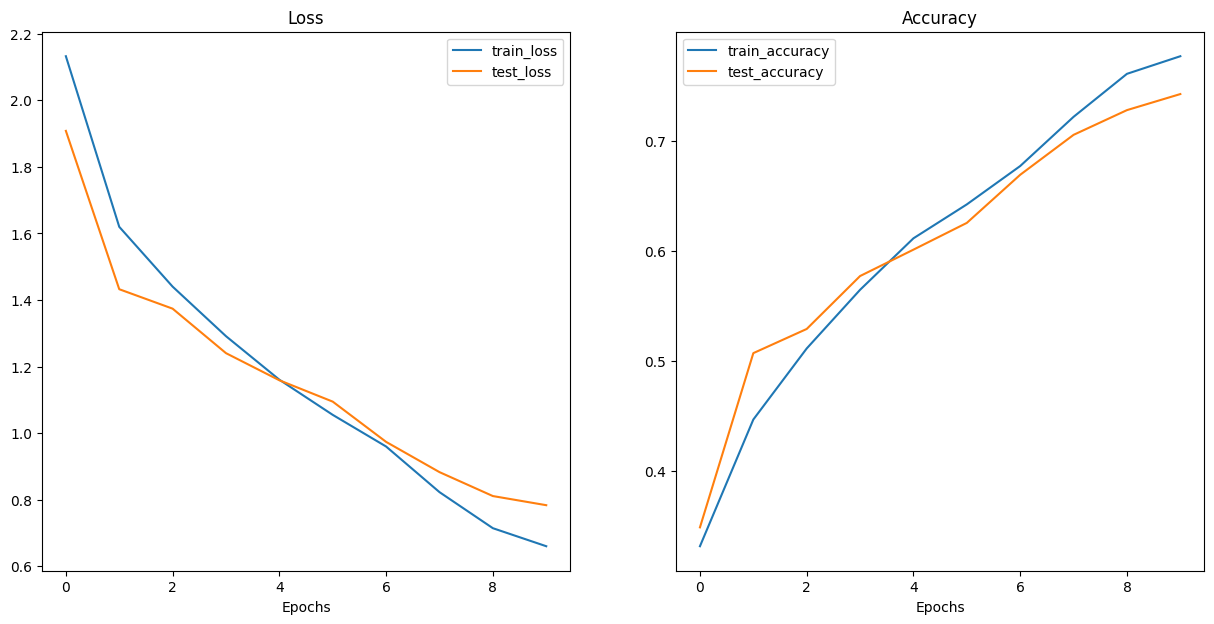

In [ ]:
plot_loss_curves(model_0_results)

# **Saving the model weights for later use**

In [ ]:
# Mounting google drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Saving the model weights in google Collab for later use. (already done)
"""
save_path = "/content/drive/MyDrive/deep_learning_project/tinyvgg_model.pth"
torch.save(model_0.state_dict(), save_path)
"""

'\n# 1. Create models directory\nMODEL_PATH = Path("models")\nMODEL_PATH.mkdir(parents=True, exist_ok=True)\n\n# 2. Create model save path\nMODEL_NAME = "tinyvgg_model.pth"\nMODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME\n\n# 3. Save the model state dict\nprint(f"Saving model to: {MODEL_SAVE_PATH}")\ntorch.save(obj=model_0.state_dict(), # only saving the state_dict()\n           f=MODEL_SAVE_PATH)\n'

In [ ]:
#loading model weights from google collab.

tiny_VGG_loaded_model = TinyVGG(input_shape=3,
                  hidden_units=64,
                  output_shape=len(train_data.classes)).to(device)

load_path = "/content/drive/MyDrive/deep_learning_project/tinyvgg_model.pth"

tiny_VGG_loaded_model.load_state_dict(torch.load(load_path, map_location=device))

tiny_VGG_loaded_model.to(device)
tiny_VGG_loaded_model.eval()


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=F

# **now using pretrained model resnet50**

In [ ]:
def get_pretrained_resnet(output_shape: int, device: torch.device):

    # 1. Get the pretrained weights
    weights = models.ResNet50_Weights.DEFAULT

    # 2. Load the model with these weights
    model = models.resnet50(weights=weights).to(device)

    # 3. FREEZE the base layers
    # We set requires_grad=False so we don't update the millions of weights that already know what 'fur' and 'eyes' look like.
    for param in model.parameters():
        param.requires_grad = False

    # 4. Recreate the Classifier (The Head)
    # ResNet stores its classifier in a layer named 'fc' (Fully Connected)
    # We overwrite it with a new layer that maps to my number of classes (10)

    # Get the input shape of the original fc layer
    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.2), # helps prevent overfitting
        nn.Linear(512, output_shape)
    ).to(device)

    return model

device = "cuda" if torch.cuda.is_available() else "cpu"


model_transfer = get_pretrained_resnet(output_shape=10, device=device)

optimizer = torch.optim.Adam(model_transfer.fc.parameters(), lr=0.001)

print(f"Model created. Feature extractor frozen. Classifier head active.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 231MB/s]


Model created. Feature extractor frozen. Classifier head active.


In [ ]:
pretrained_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 2. Recreating datasets with this new transform
train_data_pretrained = datasets.ImageFolder(root=train_dir,
                                             transform=pretrained_transform)

test_data_pretrained = datasets.ImageFolder(root=test_dir,
                                            transform=pretrained_transform)

# 3. Recreating DataLoaders
BATCH_SIZE = 32
train_dataloader_pretrained = DataLoader(dataset=train_data_pretrained,
                                         batch_size=BATCH_SIZE,
                                         shuffle=True)

test_dataloader_pretrained = DataLoader(dataset=test_data_pretrained,
                                        batch_size=BATCH_SIZE,
                                        shuffle=False)

print("DataLoaders updated for ResNet input size (224x224)!")

DataLoaders updated for ResNet input size (224x224)!


In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 10

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-3,
    steps_per_epoch=len(train_dataloader),
    epochs=NUM_EPOCHS
)

In [ ]:
# Start the timer
from timeit import default_timer as timer
start_time = timer()

# train model_transfer
pretrained_model_results = train(model=model_transfer,
                        train_dataloader=train_dataloader_pretrained,
                        test_dataloader=test_dataloader_pretrained,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        scheduler=scheduler,
                        epochs=NUM_EPOCHS)


end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")




  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.3620 | train_acc: 0.9160 | test_loss: 0.0978 | test_acc: 0.9731
Epoch: 2 | train_loss: 0.1483 | train_acc: 0.9566 | test_loss: 0.1031 | test_acc: 0.9716
Epoch: 3 | train_loss: 0.1514 | train_acc: 0.9573 | test_loss: 0.1345 | test_acc: 0.9689
Epoch: 4 | train_loss: 0.1178 | train_acc: 0.9668 | test_loss: 0.1074 | test_acc: 0.9726
Epoch: 5 | train_loss: 0.0936 | train_acc: 0.9732 | test_loss: 0.1110 | test_acc: 0.9737
Epoch: 6 | train_loss: 0.0628 | train_acc: 0.9801 | test_loss: 0.1075 | test_acc: 0.9783
Epoch: 7 | train_loss: 0.0378 | train_acc: 0.9878 | test_loss: 0.1034 | test_acc: 0.9781
Epoch: 8 | train_loss: 0.0266 | train_acc: 0.9912 | test_loss: 0.1048 | test_acc: 0.9813
Epoch: 9 | train_loss: 0.0173 | train_acc: 0.9951 | test_loss: 0.0967 | test_acc: 0.9830
Epoch: 10 | train_loss: 0.0132 | train_acc: 0.9957 | test_loss: 0.0982 | test_acc: 0.9827
Total training time: 1542.091 seconds


# **using a pretrained model we got amazing results:**  
Epoch: 1 | train_loss: 0.3680 | train_acc: 0.9140 | test_loss: 0.1095 | test_acc: 0.9684        
Epoch: 2 | train_loss: 0.1473 | train_acc: 0.9557 | test_loss: 0.1051 | test_acc: 0.9688     
Epoch: 3 | train_loss: 0.1520 | train_acc: 0.9561 | test_loss: 0.0952 | test_acc: 0.9747       
Epoch: 4 | train_loss: 0.1241 | train_acc: 0.9666 | test_loss: 0.0917 | test_acc: 0.9729        
Epoch: 5 | train_loss: 0.0876 | train_acc: 0.9738 | test_loss: 0.1070 | test_acc: 0.9739        
Epoch: 6 | train_loss: 0.0607 | train_acc: 0.9822 | test_loss: 0.0925 | test_acc: 0.9773       
Epoch: 7 | train_loss: 0.0422 | train_acc: 0.9869 | test_loss: 0.0882 | test_acc: 0.9800         
Epoch: 8 | train_loss: 0.0243 | train_acc: 0.9923 | test_loss: 0.0834 | test_acc: 0.9811         
Epoch: 9 | train_loss: 0.0152 | train_acc: 0.9951 | test_loss: 0.0843 | test_acc: 0.9809        
Epoch: 10 | train_loss: 0.0135 | train_acc: 0.9961 | test_loss: 0.0792 | test_acc: 0.9823        

In [ ]:
# Saving the model to goole collab. (already done)
'''
save_path = "/content/drive/MyDrive/deep_learning_project/resnet50_model.pth"
torch.save(model_transfer.state_dict(), save_path)
'''

In [ ]:
#loading the model from google collab.
resnet_50_loaded_model = get_pretrained_resnet(output_shape=10, device=device)

load_path = "/content/drive/MyDrive/deep_learning_project/resnet50_model.pth"

resnet_50_loaded_model.load_state_dict(torch.load(load_path, map_location=device))

resnet_50_loaded_model.to(device)
resnet_50_loaded_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# **now we will use "resnet50 loaded model" to predict random images**

In [ ]:
image_transform_resnet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# load image from URL
def load_image_from_url(url):
    response = requests.get(url, stream=True)
    response.raise_for_status()
    image = Image.open(response.raw).convert("RGB")
    return image

# prepare image for the model
def prepare_image(image, device):
    image = image_transform_resnet(image)
    image = image.unsqueeze(0)
    return image.to(device)

#make prediction
def predict_image(model, image_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.softmax(logits, dim=1)
        confidence, predicted_class = torch.max(probs, dim=1)

    return predicted_class.item(), confidence.item()


def make_prediction(image_url):
  image = load_image_from_url(image_url)
  image_tensor = prepare_image(image, device)

  pred_class, conf = predict_image(resnet_50_loaded_model, image_tensor)

  plt.figure(figsize=(5, 5))
  plt.imshow(image)
  plt.axis("off")
  plt.title(f"Predicted: {animals_en[class_names[pred_class]]} ({conf:.2%})")
  plt.show()

In [ ]:
animals_en = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}

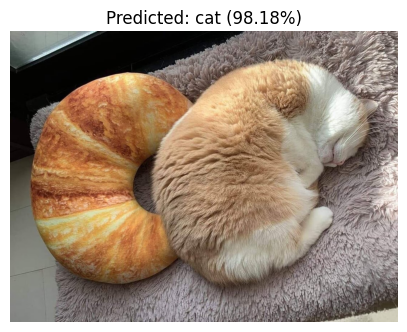

In [ ]:
image_url = "https://preview.redd.it/jr8uwjc54l761.jpg?width=1080&crop=smart&auto=webp&s=fc941c24c44ae0b947cd6187f74b77f09738c961"
make_prediction(image_url)

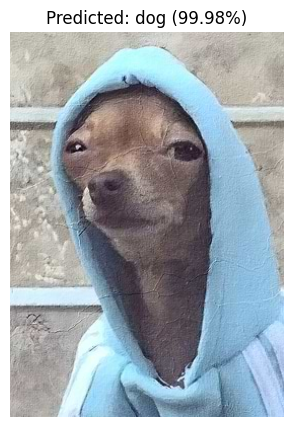

In [ ]:
image_url = "https://cdn.displate.com/artwork/270x380/2023-07-07/36564f7949ef83fec3743ccd3bbcabc2_20665b5530dd3d5737abad41cda98d27.jpg"
make_prediction(image_url)